<a href="https://colab.research.google.com/github/你的用户名/你的仓库名/blob/main/demo.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 🧬 单细胞重构指南：从线性幻象走向三维真实

> **前言**：这篇文档是为了帮你理清单细胞分析底层逻辑的“第一性原理”。我们不再只是盲目调用 R 语言的 `Seurat` 软件包，而是要从数学和物理的角度，重构细胞在数字世界的生命轨迹。

------

## 一、 传统 R 语言流程的“平庸陷阱”

大多数人使用的 R 语言流程（PCA + 2D UMAP）本质上是在做**线性降维**。

### 1. 数学原理：PCA (主成分分析)

PCA 试图找到数据中方差（Variance）最大的方向。

- **数学核心**：求解协方差矩阵 $\Sigma$ 的特征值分解：

  $$\Sigma v = \lambda v$$

  其中 $\lambda$ 是特征值，代表了该维度的信息量（解释力）。

- **架构缺陷**：它是**线性**的。如果基因之间的表达关系是复杂的曲线（如发育路径），PCA 只能抓到一个苍白的“投影”。这就像是用手电筒照着飞鸟在墙上的影子，你永远看不清它羽毛的颜色。

------

## 二、 我们的重构：深度生成模型 (VAE)

我们引入了 **VAE（变分自编码器）**。

### 1. 数学原理：非线性流形学习

VAE 不再是简单的投影，它在学习数据的**概率分布**。

- **损失函数 (Loss Function)**：我们让模型去最小化 $ELBO$（证据下界）：

  $$Loss = \|x - \hat{x}\|^2 + \beta \cdot KL(q(z|x) \| p(z))$$

  - **重建误差 ($\|x - \hat{x}\|^2$)**：确保降维后的数据还能“变回来”，保住了细节。
  - **KL 散度 ($KL$)**：强迫隐空间服从正态分布，确保细胞群落分布得更加丝滑、有逻辑。

### 2. 为什么更好？

它能捕捉基因之间复杂的**非线性相互作用**。在你的 VAE 结果图中，原本在 R 里混在一起的亚群会被精准分离，因为神经网络看穿了它们底层表达的微小波动。

------

## 三、 视觉降临：3D 动态流形

### 1. 维度破局

我们将的 `n_components` 设为 **3**。

- **逻辑**：细胞的生命周期是连续的，在 3D 空间中，你可以看到细胞是如何从一个 Cluster 像“溪流”一样迁移到另一个 Cluster 的。这在 2D 平面上是完全无法呈现的拓扑细节。

------

## 四、 实际操作代码 (Python/Scanpy)

你可以直接运行以下代码块，感受数据在指尖转动的魅力。


------



In [2]:
# 下载依赖以及数据集
!pip install scanpy leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 93.8 MB/s eta 0:00:00


正在加载数据...


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


开始在 cpu 上训练...
Epoch 5, Loss: 1649.8434
Epoch 10, Loss: 1624.1770
Epoch 15, Loss: 1615.0536
Epoch 20, Loss: 1610.4952
✅ 任务完成！VAE 特征已存入 adata.obsm['X_vae']


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38477 (\N{CJK UNIFIED IDEOGRAPH-964D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


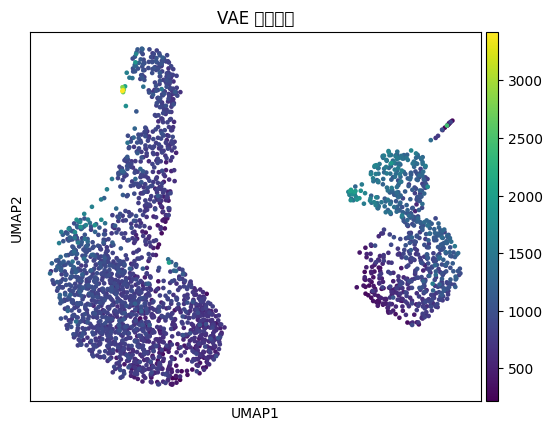

In [3]:
import scanpy as sc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# 重新加载并预处理数据
print("正在加载数据...")
adata = sc.datasets.pbmc3k()

# 剔除少于200个的数据
sc.pp.filter_cells(adata, min_genes=200)
# 提出对细胞群贡献小的数据（至少要在3个群里出现）
sc.pp.filter_genes(adata, min_cells=3)

# 标准化（缩放至1e4）
sc.pp.normalize_total(adata, target_sum=1e4)
# 取对数是分布更平滑
sc.pp.log1p(adata)

# 只选出波动最大（最能体现分布）的2000个基因
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable].copy()

# 把所有基因的表达量变成均值为 0、方差为 1 的状态
sc.pp.scale(adata, max_value=10)

# 准备 Tensor 数据
# 转换成稠密矩阵，节省内存
X_data = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X

# 转换成PyTorch架构中的张量
X_tensor = torch.FloatTensor(X_data)

# 把张量存入数据集
dataset = TensorDataset(X_tensor)
# 建立流水线（每次只喂128个， 每次训练打乱顺序）
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# 定义 VAE 模型
class SimpleVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super(SimpleVAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

# 初始化与训练
# 检查系统是否有 NVIDIA GPU (CUDA) 可用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 获取特征矩阵的列数，告诉模型输入向量的宽度
input_dim = X_tensor.shape[1]
# 模型实例化
model = SimpleVAE(input_dim=input_dim).to(device)
# 初始化Adam优化器，学习率1e-3
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(f"开始在 {device} 上训练...")
model.train()

# 迭代周期：20次
for epoch in range(20):
    total_loss = 0
    for batch in dataloader:
        x_batch = batch[0].to(device)
        recon, mu, logvar = model(x_batch)

        # Loss = 重建误差 + KL 散度
        recon_loss = nn.functional.mse_loss(recon, x_batch, reduction='sum')
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataset):.4f}")

# 提取特征并保存回 adata
model.eval()
with torch.no_grad():
    _, latent_feat, _ = model(X_tensor.to(device))
    adata.obsm["X_vae"] = latent_feat.cpu().numpy()

print("✅ 任务完成！VAE 特征已存入 adata.obsm['X_vae']")

# 查看结果
sc.pp.neighbors(adata, use_rep="X_vae")
sc.tl.umap(adata)
sc.pl.umap(adata, color='n_genes', title="Latent Space Representation (VAE)")

In [6]:
import scanpy as sc
import plotly.express as px
import plotly.io as pio
import pandas as pd

# 开启 Colab 渲染模式
pio.renderers.default = 'colab'

# 1. 降维计算 (基于训练好的 VAE 隐空间)
# 这里 n_components=3 是开启上帝视角的钥匙
sc.tl.umap(adata, n_components=3)

# Perform Leiden clustering to create the 'leiden' column
sc.tl.leiden(adata)

# 数据整合
df = pd.DataFrame(
    adata.obsm['X_umap'],
    columns=['Dim1', 'Dim2', 'Dim3'],
    index=adata.obs_names
)
df['cluster'] = adata.obs['leiden'].astype(str)

# 3D 渲染
fig = px.scatter_3d(
    df, x='Dim1', y='Dim2', z='Dim3',
    color='cluster',
    title="VAE-based 3D Cellular Manifold",
    template="plotly_dark",
    opacity=0.7
)

# 交互式可视化
fig.update_traces(marker=dict(size=2))
fig.show()

/tmp/ipykernel_1337/969123903.py:14: FutureWarning:

The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.



In [8]:
import plotly.graph_objects as go
import numpy as np

# 选择一个高度相关的基因进行可视化 (例如高变基因中的第一个)
target_gene = adata.var_names[0]
expression = adata[:, target_gene].X.toarray().flatten() if hasattr(adata.X, 'toarray') else adata[:, target_gene].X.flatten()

# 准备绘图数据
df_3d = pd.DataFrame(
    adata.obsm['X_umap'],
    columns=['x', 'y', 'z'],
    index=adata.obs_names
)
df_3d['expression'] = expression
df_3d['cluster'] = adata.obs['leiden'].astype(str)

# 创建科技感 3D 散点/气泡图，模拟 3D 分布感
fig = go.Figure(data=[go.Scatter3d(
    x=df_3d['x'],
    y=df_3d['y'],
    z=df_3d['z'],
    mode='markers',
    marker=dict(
        size=expression * 2 + 1, # 表达量越高，点越大
        color=expression,        # 颜色映射表达量
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title=f'Gene: {target_gene}', thickness=20)
    ),
    text=df_3d['cluster'],
    hovertemplate='Cluster: %{text}<br>Expression: %{marker.color:.2f}<extra></extra>'
)])

fig.update_layout(
    title=dict(text=f"基因流形分布: {target_gene}", font=dict(color='cyan')),
    template="plotly_dark",
    scene=dict(
        xaxis=dict(backgroundcolor="rgb(10, 10, 20)", gridcolor="gray", showbackground=True),
        yaxis=dict(backgroundcolor="rgb(10, 10, 20)", gridcolor="gray", showbackground=True),
        zaxis=dict(backgroundcolor="rgb(10, 10, 20)", gridcolor="gray", showbackground=True)
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

/tmp/ipykernel_1337/3893480977.py:31: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



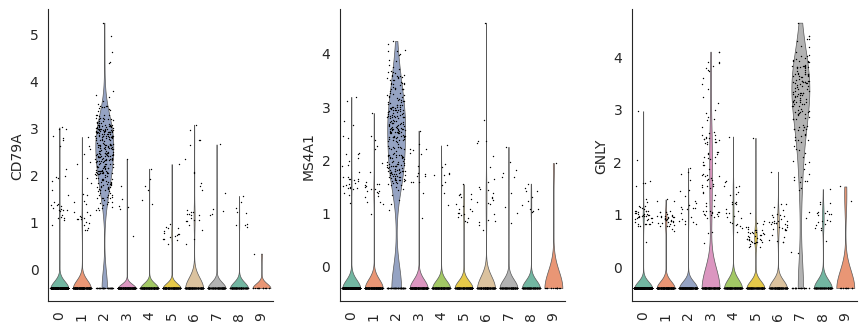

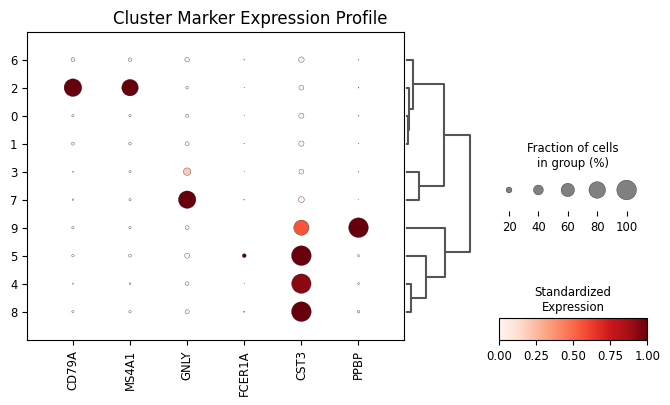

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 解决字体缺失问题，改用 Colab 自带的通用字体
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42

# 挑选存在的标记基因
requested_genes = ['IL7R', 'CD79A', 'MS4A1', 'CD8A', 'GNLY', 'CD14', 'FCER1A', 'CST3', 'PPBP']
marker_genes = [g for g in requested_genes if g in adata.var_names]

if len(marker_genes) > 0:
    # 小提琴图
    with sns.axes_style("white"):
        axes = sc.pl.violin(adata,
                            keys=marker_genes[:min(3, len(marker_genes))],
                            groupby='leiden',
                            rotation=90,
                            stripplot=True,
                            jitter=0.4,
                            size=1,
                            linewidth=0.5,
                            palette='Set2',
                            hue='leiden', # 显式赋值以满足新版 Seaborn 要求
                            legend=False,
                            show=False)

        sns.despine()
        plt.gcf().set_size_inches(10, 4)
        plt.tight_layout()
        plt.show()

    # 预先计算聚类间的亲缘关系（进化树），使用 VAE 特征避免维度警告
    sc.tl.dendrogram(adata, groupby='leiden', use_rep='X_vae')

    sc.pl.dotplot(adata,
                  var_names=marker_genes,
                  groupby='leiden',
                  use_raw=False,
                  standard_scale='var',
                  colorbar_title='Standardized\nExpression',
                  title='Cluster Marker Expression Profile',
                  expression_cutoff=0.1,
                  dendrogram=True,
                  figsize=(8, 4))
else:
    print("数据集中未找到所选基因。")

## 五、 实验 Tips

1. **旋转观察**：用鼠标拖动图像。寻找那些“桥接”两个群落的点，它们往往是正在分化的**干细胞或前体细胞**。
2. **聚类调整**：如果你觉得分群太粗，可以修改 `sc.tl.leiden(adata, resolution=1.2)`，增大分辨率。

------

### 💡 结语

工具是为了解放双手，而算法是为了解放大脑。希望这套系统能让你从繁琐的作图中解脱出来，把时间花在更有趣的生物学发现上。